# Clinical 3T MRI — B-field Mapping (All Coordinates)

Pipeline: Load → Clean outliers → Crop static ends → Split doubles → Map time→position **(convert to SI: T, m)** → B vs z → dB/dz → B·∇B → Summary table

**All quantities are in SI units throughout** (T, m, T/m, T²/m).  
Unit conversion (G→T, mm→m) is applied once at the `map_position()` step.

**G6 is the representative coordinate** shown inline; all coordinates saved to `betterPlots/`.


## 1 · Imports & configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

# ── Config ────────────────────────────────────────────────────────────────────
DATA_FOLDER    = Path('DataCollectionFolderMRIProject')
PLOTS_DIR      = 'betterPlots'           # assumed to already exist
TOTAL_DIST_MM  = 1252.0                  # full rail travel in mm

# Unit conversion factors (applied once at map_position step)
GAUSS_TO_TESLA = 1e-4    # G  → T
MM_TO_M        = 1e-3    # mm → m

# All coordinate prefixes and their N-runs
PREFIXES = ['A6','A3','00','D3', 'G3', 'G6']
# '00' has N1-N4, all others have N1 and N2
ALL_KEYS = (
    [f'00N{i}' for i in range(1, 5)] +
    [f'{p}N{n}' for p in PREFIXES if p != '00' for n in [1, 2]]
)
# N1/N3 = forward (entering bore), N2/N4 = backward (exiting bore)
def is_backward(key): return 'N2' in key.upper() or 'N4' in key.upper()

# Instrument error model: ±1% of |B| + 0.1 mT  (converted to T)
def tesla_error(B_T): return 0.01 * np.abs(B_T) + 1.0 * GAUSS_TO_TESLA

print('Config ready.')
print(f'Coordinates: {PREFIXES}')
print(f'All run keys: {ALL_KEYS}')


Config ready.
Coordinates: ['A6', 'A3', '00', 'D3', 'G3', 'G6']
All run keys: ['00N1', '00N2', '00N3', '00N4', 'A6N1', 'A6N2', 'A3N1', 'A3N2', 'D3N1', 'D3N2', 'G3N1', 'G3N2', 'G6N1', 'G6N2']


## 2 · Load all CSV files

In [2]:
raw = {}
missing = []

for key in ALL_KEYS:
    # file naming: MRI3Tesla_G6N1.csv
    prefix = key[:-2]   # e.g. 'G6'
    fpath  = DATA_FOLDER / f'MRI3Tesla_{key}.csv'
    if not fpath.exists():
        missing.append(key)
        continue
    df = pd.read_csv(fpath)[['time', 'flux']]
    raw[key] = df

print(f"Loaded {len(raw)} files.")
if missing:
    print(f"Missing (skipped): {missing}")

# Quick sanity: show time range for each
for key, df in sorted(raw.items()):
    print(f"  {key}: {len(df):>4} rows   t = {df['time'].iloc[0]:.2f} → {df['time'].iloc[-1]:.2f} s")


Loaded 14 files.
  00N1:  120 rows   t = 0.25 → 30.00 s
  00N2:  120 rows   t = 0.25 → 30.00 s
  00N3:  120 rows   t = 0.25 → 30.00 s
  00N4:  120 rows   t = 0.25 → 30.00 s
  A3N1:  120 rows   t = 0.25 → 30.00 s
  A3N2:  120 rows   t = 0.25 → 30.00 s
  A6N1:  120 rows   t = 0.25 → 30.00 s
  A6N2:  120 rows   t = 0.25 → 30.00 s
  D3N1:  120 rows   t = 0.25 → 30.00 s
  D3N2:  120 rows   t = 0.25 → 30.00 s
  G3N1:  120 rows   t = 0.25 → 30.00 s
  G3N2:  120 rows   t = 0.25 → 30.00 s
  G6N1:  120 rows   t = 0.25 → 30.00 s
  G6N2:  120 rows   t = 0.25 → 30.00 s


## 3 · B vs Time — G6 only (representative)

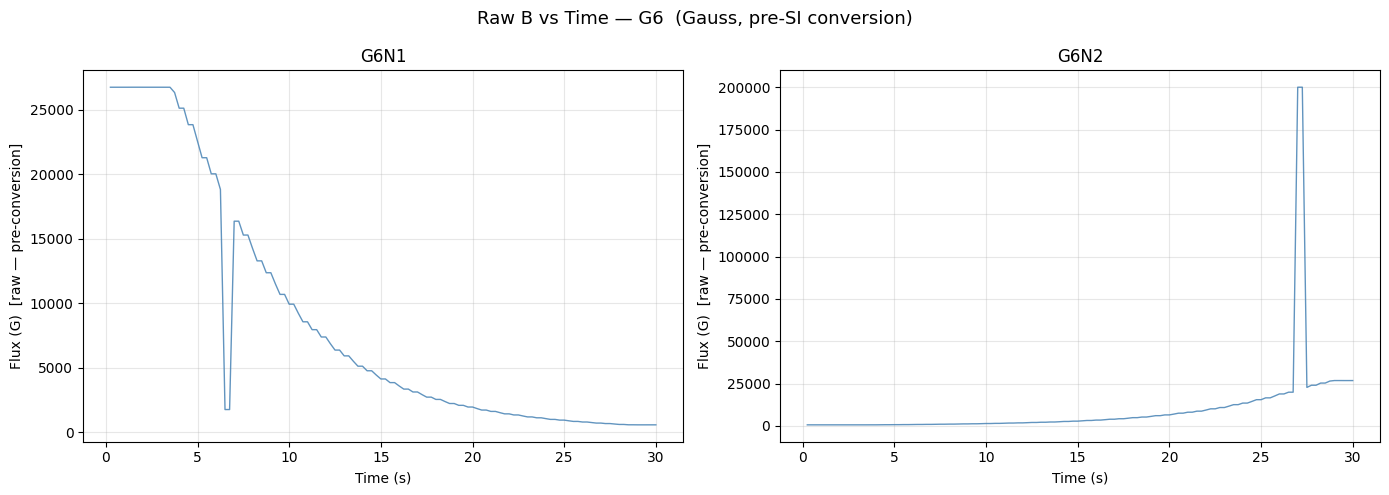

Saved G6_BvsTime_raw.png


In [3]:
# Note: B vs Time is plotted from raw data (G) — conversion happens at map_position()
g6_keys = [k for k in raw if k.startswith('G6')]

fig, axes = plt.subplots(1, len(g6_keys), figsize=(7*len(g6_keys), 5))
if len(g6_keys) == 1: axes = [axes]

for ax, key in zip(axes, g6_keys):
    df = raw[key]
    ax.plot(df['time'], df['flux'], color='steelblue', lw=1, alpha=0.85)
    ax.set_title(key)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Flux (G)  [raw — pre-conversion]')
    ax.grid(True, alpha=0.3)

fig.suptitle('Raw B vs Time — G6  (Gauss, pre-SI conversion)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/G6_BvsTime_raw.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved G6_BvsTime_raw.png')


## 4 · Remove gaussmeter artefacts (exponential 3-σ cut)

In [4]:
def remove_outliers(df, sigma_cut=3.0):
    """Fit exponential baseline; remove residuals > sigma_cut * std."""
    def exp_func(t, a, b, c): return a * np.exp(-b * t) + c
    df = df.copy().reset_index(drop=True)
    try:
        p0 = [df['flux'].max(), 0.1, df['flux'].min()]
        popt, _ = curve_fit(exp_func, df['time'], df['flux'], p0=p0, maxfev=10000)
        residuals = df['flux'] - exp_func(df['time'], *popt)
        mask = np.abs(residuals) < sigma_cut * residuals.std()
        removed = (~mask).sum()
        if removed:
            print(f"    removed {removed} outlier(s) ({100*removed/len(df):.1f}%)")
        return df[mask].reset_index(drop=True)
    except Exception as e:
        print(f"    fit failed ({e}) — keeping all")
        return df

clean = {}
for key, df in sorted(raw.items()):
    clean[key] = remove_outliers(df)
print("Outlier removal done.")


    removed 1 outlier(s) (0.8%)
    removed 1 outlier(s) (0.8%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 1 outlier(s) (0.8%)
    removed 1 outlier(s) (0.8%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
Outlier removal done.


## 5 · Crop static ends (probe not moving)

In [5]:
def crop_static_ends(df, tolerance=1.0):
    """Remove leading/trailing near-constant flux plateaus."""
    flux = df['flux'].values
    n    = len(flux)
    start = 0
    while start < n-1 and abs(flux[start] - flux[start+1]) <= tolerance:
        start += 1
    end = n-1
    while end > 0 and abs(flux[end] - flux[end-1]) <= tolerance:
        end -= 1
    if start > end:
        start, end = 0, n-1
    return df.iloc[start:end+1].reset_index(drop=True)

cropped = {}
for key, df in sorted(clean.items()):
    c = crop_static_ends(df, tolerance=1.0)
    cropped[key] = c

print("Cropping done.")
for key, df in sorted(cropped.items()):
    print(f"  {key}: {len(df):>4} rows  t = {df['time'].iloc[0]:.2f} → {df['time'].iloc[-1]:.2f} s")


Cropping done.
  00N1:  102 rows  t = 2.50 → 28.00 s
  00N2:  110 rows  t = 1.75 → 29.25 s
  00N3:   84 rows  t = 3.00 → 24.25 s
  00N4:  102 rows  t = 3.00 → 28.75 s
  A3N1:  101 rows  t = 3.50 → 29.00 s
  A3N2:  105 rows  t = 3.50 → 30.00 s
  A6N1:  111 rows  t = 0.50 → 28.25 s
  A6N2:  103 rows  t = 3.50 → 29.50 s
  D3N1:  105 rows  t = 2.25 → 28.75 s
  D3N2:  106 rows  t = 3.00 → 29.50 s
  G3N1:  100 rows  t = 3.25 → 28.25 s
  G3N2:  103 rows  t = 4.00 → 30.00 s
  G6N1:  101 rows  t = 3.50 → 29.00 s
  G6N2:  103 rows  t = 3.50 → 29.50 s


## 6 · Split duplicate samples into sub-runs A and B

The gaussmeter samples at 0.25 s but the probe moves at ~0.5 s cadence, so most
spatial positions are measured **twice** (identical flux values back-to-back).
We group consecutive identical readings and take:
- **Sub-run A** = first reading of each group
- **Sub-run B** = second reading of each group (skipped for singletons)

This gives two independent spatial sweeps per direction.


In [6]:
def split_doubles(df, tol=1.0):
    """
    Group consecutive rows with |Δflux| <= tol.
    Return (subA, subB) DataFrames sorted by time.
    subB will be shorter if some groups have only 1 reading.
    """
    flux = df['flux'].values
    groups = []
    i = 0
    while i < len(flux):
        j = i + 1
        while j < len(flux) and abs(flux[j] - flux[i]) <= tol:
            j += 1
        groups.append(list(range(i, j)))
        i = j

    idx_A = [g[0] for g in groups]
    idx_B = [g[1] for g in groups if len(g) >= 2]

    return df.iloc[idx_A].reset_index(drop=True), df.iloc[idx_B].reset_index(drop=True)

split = {}   # key → {'A': df, 'B': df}
for key, df in sorted(cropped.items()):
    A, B = split_doubles(df)
    split[key] = {'A': A, 'B': B}

print("Splitting done.")
for key, subs in sorted(split.items()):
    print(f"  {key}:  A={len(subs['A'])} pts   B={len(subs['B'])} pts")


Splitting done.
  00N1:  A=61 pts   B=41 pts
  00N2:  A=61 pts   B=41 pts
  00N3:  A=51 pts   B=33 pts
  00N4:  A=58 pts   B=36 pts
  A3N1:  A=61 pts   B=40 pts
  A3N2:  A=62 pts   B=41 pts
  A6N1:  A=64 pts   B=44 pts
  A6N2:  A=62 pts   B=41 pts
  D3N1:  A=63 pts   B=42 pts
  D3N2:  A=63 pts   B=43 pts
  G3N1:  A=60 pts   B=40 pts
  G3N2:  A=62 pts   B=41 pts
  G6N1:  A=61 pts   B=40 pts
  G6N2:  A=62 pts   B=41 pts


## 7 · Map time → position (constant average velocity)

In [7]:
def map_position(df, key, total_dist=TOTAL_DIST_MM):
    """
    Linear time→position mapping; reverse direction for N2/N4 runs.
    Converts flux G→T and position mm→m immediately so all downstream
    data is already in SI units.
    """
    df = df.copy()
    t0, t1 = df['time'].iloc[0], df['time'].iloc[-1]
    dt = t1 - t0
    if dt <= 0:
        df['position_m'] = np.nan
        df['B_T']        = np.nan
        return df
    v = total_dist / dt                           # mm/s
    pos_mm = (df['time'] - t0) * v
    if is_backward(key):
        pos_mm = total_dist - pos_mm
    # ── Convert to SI right here ──────────────────────────────────
    df['position_m'] = pos_mm * MM_TO_M           # mm → m
    df['B_T']        = df['flux'] * GAUSS_TO_TESLA  # G  → T
    # Keep originals for reference
    df['position_mm'] = pos_mm
    return df

mapped = {}   # key → {'A': df, 'B': df}
for key, subs in sorted(split.items()):
    mapped[key] = {
        sub: map_position(df, key)
        for sub, df in subs.items()
    }

print('Mapping done — positions in m, flux in T.')
# Quick sanity check
sample = next(iter(mapped.values()))['A']
print(f'  Columns: {list(sample.columns)}')
print(f'  position_m range: {sample["position_m"].min():.4f} → {sample["position_m"].max():.4f} m')
print(f'  B_T range:        {sample["B_T"].min():.4f} → {sample["B_T"].max():.4f} T')


Mapping done — positions in m, flux in T.
  Columns: ['time', 'flux', 'position_m', 'B_T', 'position_mm']
  position_m range: 0.0000 → 1.2520 m
  B_T range:        0.0569 → 2.6823 T


## 8 · Central-difference gradient helper

In [8]:
def central_diff(pos_m, B_T, bin_size_m=0.012):
    """
    Bin B_T into bin_size_m bins then apply 2nd-order central differences.
    All inputs and outputs are in SI units.

    Parameters
    ----------
    pos_m      : positions in metres
    B_T        : flux density in Tesla
    bin_size_m : bin width in metres (default 0.012 m = 12 mm, same as before)

    Returns
    -------
    z_m    : bin-centre positions (m)
    dBdz   : spatial gradient dB/dz (T/m)
    B_bin  : binned mean B (T)
    """
    pos  = np.asarray(pos_m, dtype=float)
    flux = np.asarray(B_T,   dtype=float)

    order = np.argsort(pos)
    pos, flux = pos[order], flux[order]

    bins = np.arange(np.floor(pos.min() / bin_size_m) * bin_size_m,
                     np.ceil( pos.max() / bin_size_m) * bin_size_m + bin_size_m,
                     bin_size_m)
    idx  = np.digitize(pos, bins)
    z_b, B_b = [], []
    for i in range(1, len(bins)):
        m = idx == i
        if m.sum() > 0:
            z_b.append(pos[m].mean())
            B_b.append(flux[m].mean())

    z_b  = np.array(z_b)
    B_b  = np.array(B_b)
    n    = len(z_b)
    dBdz = np.full(n, np.nan)

    dz_c = z_b[2:] - z_b[:-2]
    dz_c[dz_c == 0] = np.nan
    dBdz[1:-1] = (B_b[2:] - B_b[:-2]) / dz_c     # T/m  (SI in, SI out)

    dz_l = z_b[1]  - z_b[0]
    dz_r = z_b[-1] - z_b[-2]
    if dz_l != 0: dBdz[0]  = (B_b[1]  - B_b[0])  / dz_l
    if dz_r != 0: dBdz[-1] = (B_b[-1] - B_b[-2]) / dz_r

    # Clip top 2% outliers
    finite = dBdz[np.isfinite(dBdz)]
    if len(finite):
        hi = np.percentile(np.abs(finite), 98)
        dBdz[np.abs(dBdz) > hi] = np.nan

    return z_b, dBdz, B_b

print('central_diff() ready  —  inputs: (m, T)  →  outputs: (m, T/m, T)')


central_diff() ready  —  inputs: (m, T)  →  outputs: (m, T/m, T)


## 9 · Plot helper (runs all coordinates, saves to betterPlots/)

In [9]:
SUB_COLORS  = {'A': 'steelblue',   'B': 'darkorange'}
SUB_LABELS  = {'A': 'Sub-run A',   'B': 'Sub-run B'}
PASS_TITLES = {'fwd': 'Forward (entering bore)', 'bwd': 'Backward (exiting bore)'}

def get_pass_keys(prefix):
    """Return (forward_keys, backward_keys) for a given coordinate prefix."""
    all_k = [k for k in mapped if k.startswith(prefix)]
    bwd   = [k for k in all_k if not is_backward(k)]
    fwd   = [k for k in all_k if     is_backward(k)]
    return fwd, bwd

def plot_coordinate(prefix, show=False):
    """
    For one coordinate, produce three figures (B, dB/dz, B·dB/dz),
    each with Forward | Backward subplots, all sub-runs overlaid.
    All axes are in SI units (m, T, T/m, T²/m).
    """
    fwd_keys, bwd_keys = get_pass_keys(prefix)
    pass_map = {'fwd': fwd_keys, 'bwd': bwd_keys}

    # ── B vs position (T vs m) ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (pass_label, keys) in zip(axes, pass_map.items()):
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position_m'].notna() & df['B_T'].notna()
                ax.plot(df.loc[ok, 'position_m'], df.loc[ok, 'B_T'],
                        color=SUB_COLORS[sub], lw=1.2, alpha=0.75,
                        label=f'{key} {SUB_LABELS[sub]}')
        ax.set_xlabel('Position (m)')
        ax.set_ylabel('B (T)')
        ax.set_title(PASS_TITLES[pass_label])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{prefix} — B vs Position', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{prefix}_BvsPosition.png', dpi=300, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close()

    # ── dB/dz vs position (T/m vs m) ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (pass_label, keys) in zip(axes, pass_map.items()):
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position_m'].notna() & df['B_T'].notna()
                if ok.sum() < 3: continue
                z_m, dBdz, _ = central_diff(
                    df.loc[ok, 'position_m'].values,
                    df.loc[ok, 'B_T'].values
                )
                ok_g = np.isfinite(dBdz)
                ax.plot(z_m[ok_g], dBdz[ok_g],
                        color=SUB_COLORS[sub], lw=1.2, alpha=0.75,
                        label=f'{key} {SUB_LABELS[sub]}')
        ax.set_xlabel('Position (m)')
        ax.set_ylabel('dB/dz (T/m)')
        ax.set_title(PASS_TITLES[pass_label])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{prefix} — dB/dz vs Position', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{prefix}_dBdz_vsPosition.png', dpi=300, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close()

    # ── B·dB/dz vs position (T²/m vs m) ─────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (pass_label, keys) in zip(axes, pass_map.items()):
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position_m'].notna() & df['B_T'].notna()
                if ok.sum() < 3: continue
                z_m, dBdz, B_bin = central_diff(
                    df.loc[ok, 'position_m'].values,
                    df.loc[ok, 'B_T'].values
                )
                BgradB = B_bin * dBdz
                ok_bg  = np.isfinite(BgradB)
                ax.plot(z_m[ok_bg], BgradB[ok_bg],
                        color=SUB_COLORS[sub], lw=1.2, alpha=0.75,
                        label=f'{key} {SUB_LABELS[sub]}')
        ax.set_xlabel('Position (m)')
        ax.set_ylabel('B·dB/dz (T²/m)')
        ax.set_title(PASS_TITLES[pass_label])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{prefix} — B·dB/dz vs Position', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{prefix}_BgradB_vsPosition.png', dpi=300, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close()

print('plot_coordinate() ready  —  all axes in SI (m, T, T/m, T²/m)')


plot_coordinate() ready  —  all axes in SI (m, T, T/m, T²/m)


## 10 · Generate all plots (G6 shown inline, rest saved silently)

  A6: saved B, dB/dz, B·dB/dz plots 
  A3: saved B, dB/dz, B·dB/dz plots 
  00: saved B, dB/dz, B·dB/dz plots 
  D3: saved B, dB/dz, B·dB/dz plots 
  G3: saved B, dB/dz, B·dB/dz plots 


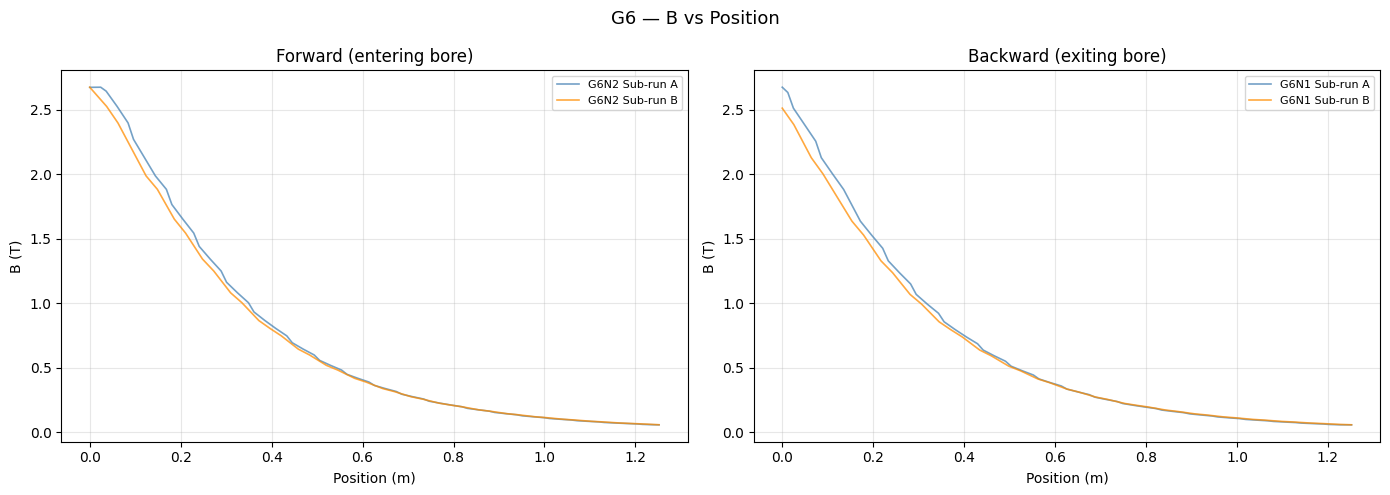

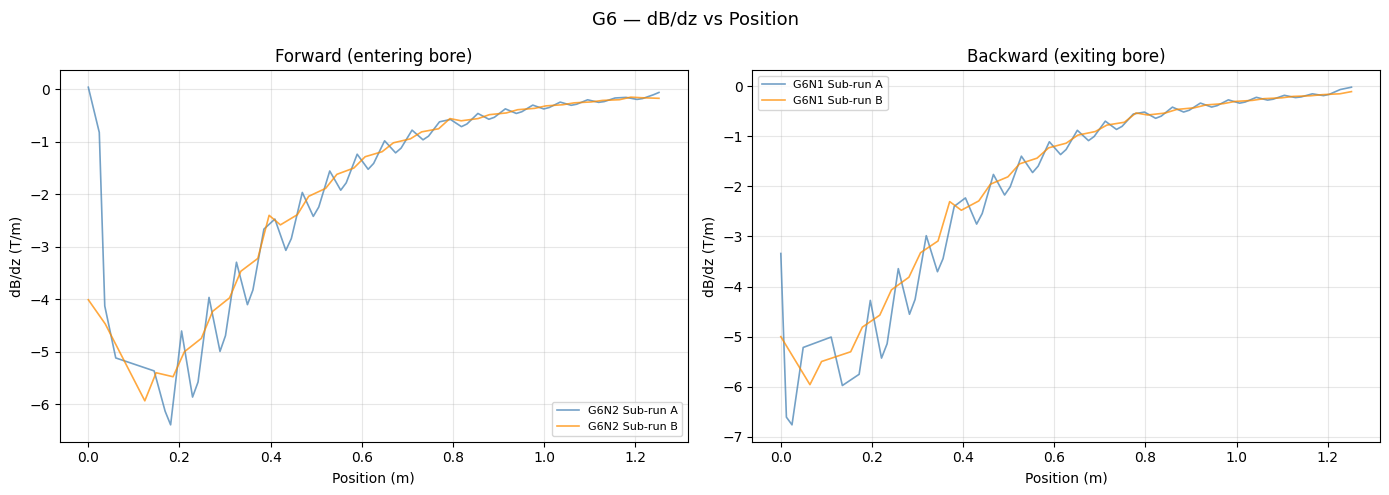

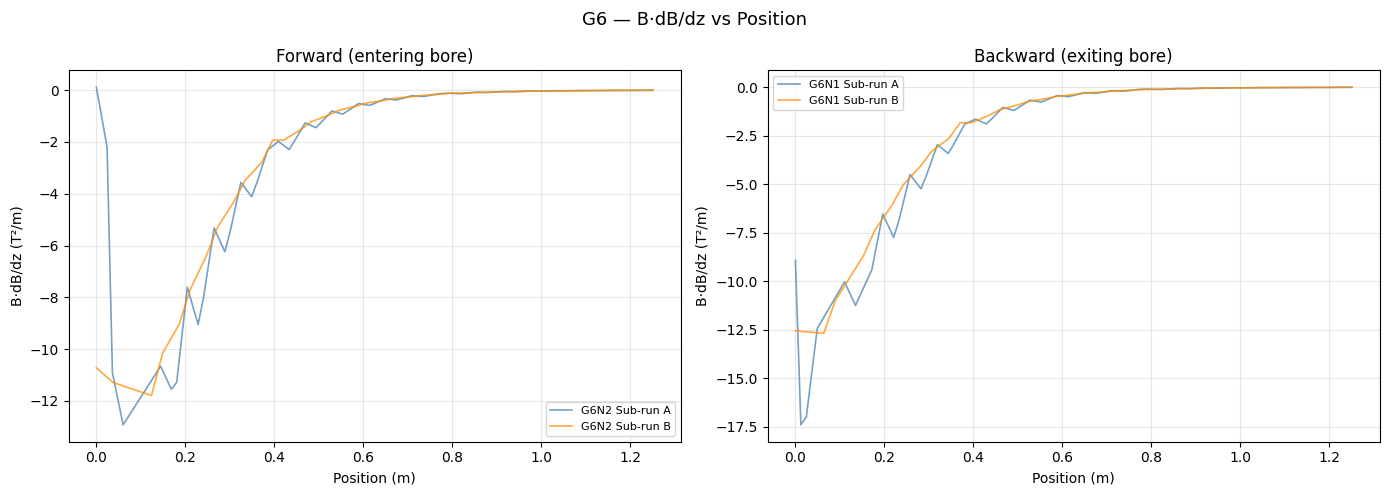

  G6: saved B, dB/dz, B·dB/dz plots (shown inline)


In [10]:
for prefix in PREFIXES:
    keys_present = [k for k in mapped if k.startswith(prefix)]
    if not keys_present:
        print(f"  {prefix}: no data found, skipping")
        continue
    show_inline = (prefix == 'G6')
    plot_coordinate(prefix, show=show_inline)
    print(f"  {prefix}: saved B, dB/dz, B·dB/dz plots {'(shown inline)' if show_inline else ''}")


## 11 · Summary — max |B·dB/dz| per coordinate in SI units

In [11]:
summary_rows = []

for prefix in PREFIXES:
    fwd_keys, bwd_keys = get_pass_keys(prefix)

    for pass_name, keys in [('Forward', fwd_keys), ('Backward', bwd_keys)]:
        for key in keys:
            for sub, df in sorted(mapped[key].items()):
                ok = df['position_m'].notna() & df['B_T'].notna()
                if ok.sum() < 3:
                    continue

                pos  = df.loc[ok, 'position_m'].values   # m
                B    = df.loc[ok, 'B_T'].values           # T

                # ── Max |B| (T) ────────────────────────────────────────────
                idx_maxB = np.argmax(np.abs(B))
                max_B    = B[idx_maxB]                    # T
                pos_maxB = pos[idx_maxB]                  # m

                # ── Gradient (T/m) ─────────────────────────────────────────
                z_m, dBdz, B_bin = central_diff(pos, B)  # all SI
                ok_g = np.isfinite(dBdz)
                if ok_g.sum() == 0:
                    continue
                idx_maxG  = np.nanargmax(np.abs(dBdz[ok_g]))
                max_grad  = dBdz[ok_g][idx_maxG]          # T/m
                pos_maxG  = z_m[ok_g][idx_maxG]           # m

                # ── B·dB/dz (T²/m) ────────────────────────────────────────
                BgradB     = B_bin * dBdz
                ok_bg      = np.isfinite(BgradB)
                idx_maxBg  = np.nanargmax(np.abs(BgradB[ok_bg]))
                max_BgradB = BgradB[ok_bg][idx_maxBg]     # T²/m
                pos_maxBg  = z_m[ok_bg][idx_maxBg]        # m

                # ── General behaviour ──────────────────────────────────────
                B_range  = B.max() - B.min()
                trend    = 'rises' if B[-1] > B[0] else 'falls'
                behaviour = (f"B {trend} by {B_range*1e3:.1f} mT over "
                             f"{pos.min()*1e3:.0f}–{pos.max()*1e3:.0f} mm")

                summary_rows.append({
                    'coord':            prefix,
                    'pass':             pass_name,
                    'sub_run':          sub,
                    'max_B_T':          max_B,          # T
                    'pos_maxB_m':       pos_maxB,       # m
                    'max_gradB_Tm':     max_grad,       # T/m
                    'pos_maxG_m':       pos_maxG,       # m
                    'max_BgradB_T2m':   max_BgradB,     # T²/m
                    'pos_maxBg_m':      pos_maxBg,      # m
                    'behaviour':        behaviour,
                })

# ── Print table ───────────────────────────────────────────────────────────────
hdr = (f"{'Coord':>6} {'Pass':>9} {'Sub':>4}  "
       f"{'max|B|(T)':>10} {'@(m)':>7}  "
       f"{'max|dB/dz|(T/m)':>16} {'@(m)':>7}  "
       f"{'max|B·∇B|(T²/m)':>16} {'@(m)':>7}")
print(hdr)
print('-' * len(hdr))
for r in summary_rows:
    print(f"{r['coord']:>6} {r['pass']:>9} {r['sub_run']:>4}  "
          f"{abs(r['max_B_T']):>10.4f} {r['pos_maxB_m']:>7.4f}  "
          f"{abs(r['max_gradB_Tm']):>16.4f} {r['pos_maxG_m']:>7.4f}  "
          f"{abs(r['max_BgradB_T2m']):>16.5f} {r['pos_maxBg_m']:>7.4f}")
print()

# ── General behaviour ─────────────────────────────────────────────────────────
print('General behaviour:')
seen = set()
for r in summary_rows:
    k = (r['coord'], r['pass'], r['sub_run'])
    if k not in seen:
        seen.add(k)
        print(f"  {r['coord']:>6} {r['pass']:>9} sub-{r['sub_run']}:  {r['behaviour']}")

print()
print('Note: Sub-run A may show sawtooth-like gradients due to irregular position')
print('spacing caused by singletons (positions sampled only once) interspersed')
print('among paired readings. Sub-run B has more uniform spacing and cleaner')
print('gradient profiles. Left for further consideration.')

summary_df = pd.DataFrame(summary_rows)
summary_df


 Coord      Pass  Sub   max|B|(T)    @(m)   max|dB/dz|(T/m)    @(m)   max|B·∇B|(T²/m)    @(m)
---------------------------------------------------------------------------------------------
    A6   Forward    A      2.9722  0.0241            9.4941  0.1445          22.80846  0.0843
    A6   Forward    B      2.9722  0.0000            8.9077  0.0876          21.22703  0.0876
    A6  Backward    A      2.9543  0.0113            9.8440  0.1241          27.90678  0.1241
    A6  Backward    B      2.9543  0.0000           10.3911  0.1739          22.95190  0.1739
    A3   Forward    A      2.7773  0.0000            7.7666  0.1654          16.28303  0.0827
    A3   Forward    B      2.7770  0.0000            7.4395  0.0620          18.33309  0.0620
    A3  Backward    A      2.7815  0.0000            7.9053  0.0245          20.79877  0.0245
    A3  Backward    B      2.6310  0.0000            7.2326  0.0639          16.30022  0.0000
    00   Forward    A      2.6851  0.0248            6.4808 

,coord,pass,sub_run,max_B_T,pos_maxB_m,max_gradB_Tm,pos_maxG_m,max_BgradB_T2m,pos_maxBg_m,behaviour
0,A6,Forward,A,2.9722,0.024077,-9.494070,0.144462,-22.808461,0.084269,B rises by 2923.0 mT over 0–1252 mm
1,A6,Forward,B,2.9722,0.000000,-8.907691,0.087640,-21.227027,0.087640,B rises by 2919.0 mT over 0–1252 mm
2,A6,Backward,A,2.9543,0.011279,-9.844010,0.124072,-27.906783,0.124072,B falls by 2905.2 mT over 0–1252 mm
3,A6,Backward,B,2.9543,0.000000,-10.391118,0.173889,-22.951902,0.173889,B falls by 2903.8 mT over 0–1252 mm
4,A3,Forward,A,2.7773,0.000000,-7.766617,0.165358,-16.283034,0.082679,B rises by 2723.6 mT over 0–1252 mm
5,A3,Forward,B,2.7770,0.000000,-7.439473,0.061980,-18.333093,0.061980,B rises by 2722.6 mT over 0–1252 mm
6,A3,Backward,A,2.7815,0.000000,-7.905272,0.024549,-20.798769,0.024549,B falls by 2727.8 mT over 0–1252 mm
7,A3,Backward,B,2.6310,0.000000,-7.232588,0.063878,-16.300222,0.000000,B falls by 2576.6 mT over 0–1252 mm
8,00,Forward,A,2.6851,0.024792,-6.480780,0.136356,-13.992003,0.136356,B rises by 2628.1 mT over 0–1252 mm
9,00,Forward,B,2.6851,0.025040,-6.243450,0.175280,-14.599673,0.087640,B rises by 2627.2 mT over 0–1252 mm


# 9. Save as pickle

In [12]:
import pickle, os
os.makedirs('outputs', exist_ok=True)

with open('outputs/clinical_summary.pkl', 'wb') as f:
    pickle.dump(summary_df, f)
print("✅ Saved clinical_summary.pkl")

✅ Saved clinical_summary.pkl


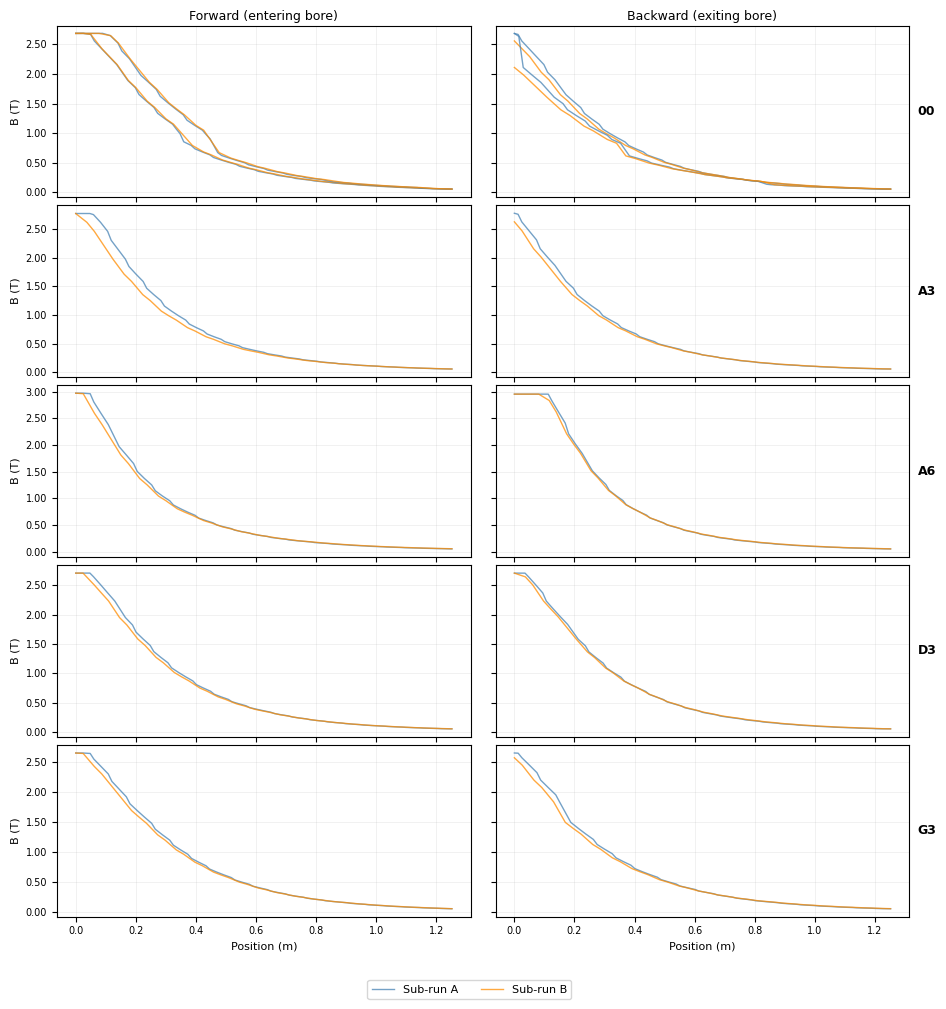

Saved allCoords_betterPlots/summary_B.png


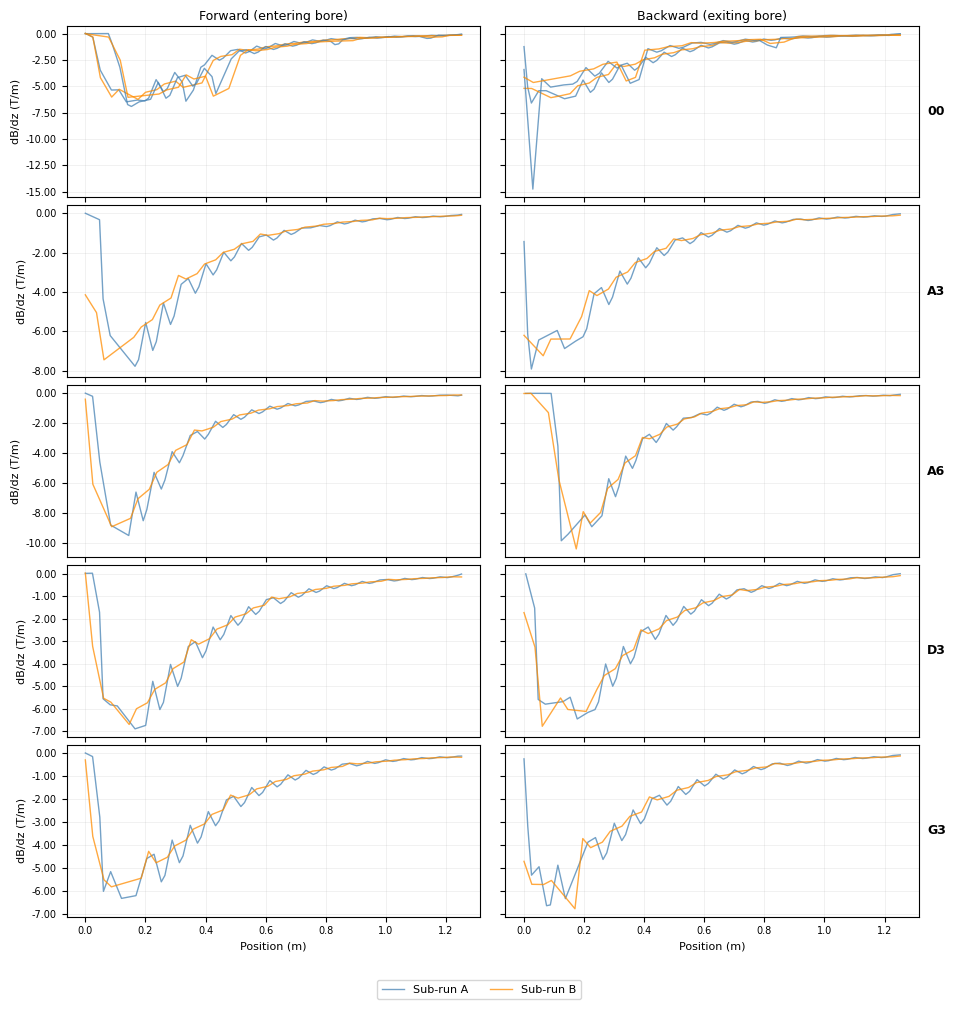

Saved allCoords_betterPlots/summary_dBdz.png


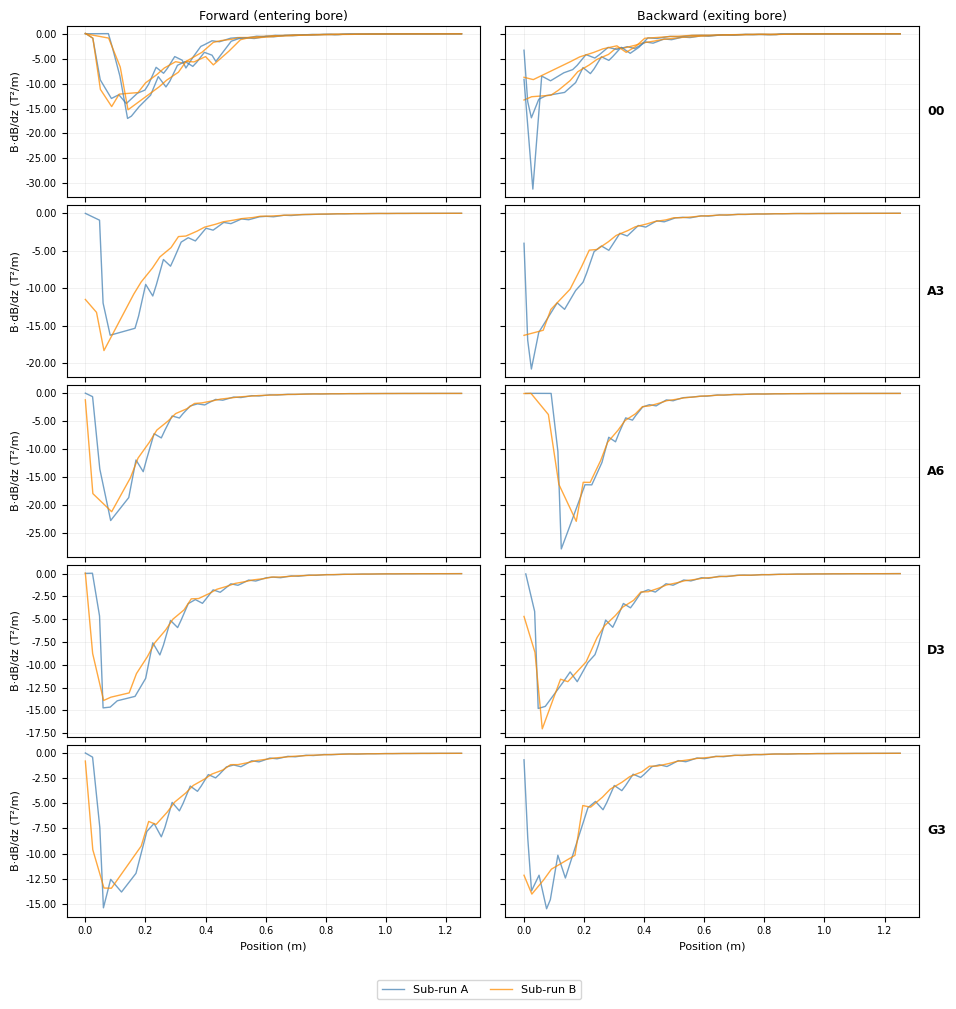

Saved allCoords_betterPlots/summary_BgradB.png


In [13]:
## ── Summary figures (append at end of notebook) ──────────────────────────────
## Assumes: mapped, central_diff, is_backward, SUB_COLORS, SUB_LABELS,
##          PREFIXES (without G6), get_pass_keys  — all already defined above.

import matplotlib.ticker as ticker

SUMMARY_DIR = Path('allCoords_betterPlots')
SUMMARY_DIR.mkdir(exist_ok=True)

SUMMARY_PREFIXES = ['00', 'A3', 'A6', 'D3', 'G3']   # exclude G6

def make_summary_figure(plot_type):
    """
    plot_type : 'B' | 'dBdz' | 'BgradB'
    Layout    : 5 rows (coords) × 2 cols (Forward | Backward)
    - No per-subplot titles (handled in LaTeX)
    - Shared x-axis label on bottom row only
    - Shared y-axis label on left column only
    - Coord name annotated on right of each row
    - Minimal whitespace between panels
    """
    nrows = len(SUMMARY_PREFIXES)
    ncols = 2

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(11, 2.2 * nrows),
        sharex='col',
        sharey='row',
        gridspec_kw=dict(hspace=0.05, wspace=0.06)
    )

    col_titles = ['Forward (entering bore)', 'Backward (exiting bore)']
    y_labels   = {
        'B':      'B (T)',
        'dBdz':   'dB/dz (T/m)',
        'BgradB': r'B·dB/dz (T²/m)',
    }

    for row, prefix in enumerate(SUMMARY_PREFIXES):
        fwd_keys, bwd_keys = get_pass_keys(prefix)
        pass_map = [('fwd', fwd_keys), ('bwd', bwd_keys)]

        for col, (pass_label, keys) in enumerate(pass_map):
            ax = axes[row, col]

            for key in keys:
                for sub, df in mapped[key].items():
                    ok = df['position_m'].notna() & df['B_T'].notna()
                    if ok.sum() < 3:
                        continue

                    pos = df.loc[ok, 'position_m'].values
                    B   = df.loc[ok, 'B_T'].values

                    if plot_type == 'B':
                        ax.plot(pos, B,
                                color=SUB_COLORS[sub], lw=1.0, alpha=0.75,
                                label=SUB_LABELS[sub])

                    elif plot_type == 'dBdz':
                        z_m, dBdz, _ = central_diff(pos, B)
                        ok_g = np.isfinite(dBdz)
                        ax.plot(z_m[ok_g], dBdz[ok_g],
                                color=SUB_COLORS[sub], lw=1.0, alpha=0.75,
                                label=SUB_LABELS[sub])

                    elif plot_type == 'BgradB':
                        z_m, dBdz, B_bin = central_diff(pos, B)
                        BgradB = B_bin * dBdz
                        ok_bg  = np.isfinite(BgradB)
                        ax.plot(z_m[ok_bg], BgradB[ok_bg],
                                color=SUB_COLORS[sub], lw=1.0, alpha=0.75,
                                label=SUB_LABELS[sub])

            ax.grid(True, alpha=0.25, lw=0.5)
            ax.tick_params(labelsize=7)
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

            # Column headers — top row only
            if row == 0:
                ax.set_title(col_titles[col], fontsize=9, pad=4)

            # x-label — bottom row only
            if row == nrows - 1:
                ax.set_xlabel('Position (m)', fontsize=8)

            # y-label — left column only
            if col == 0:
                ax.set_ylabel(y_labels[plot_type], fontsize=8)

        # Coord label on the right of each row
        axes[row, -1].annotate(
            prefix,
            xy=(1.02, 0.5), xycoords='axes fraction',
            fontsize=9, fontweight='bold', va='center', ha='left',
        )

    # Single shared legend at the bottom
    handles, labels_seen = [], set()
    handle_list, label_list = [], []
    for ax in axes.flat:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels_seen:
                handle_list.append(h)
                label_list.append(l)
                labels_seen.add(l)
    fig.legend(handle_list, label_list,
               loc='lower center', ncol=2, fontsize=8,
               frameon=True, bbox_to_anchor=(0.5, -0.01))

    fig.subplots_adjust(bottom=0.07)

    out_path = SUMMARY_DIR / f'summary_{plot_type}.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {out_path}')


for pt in ['B', 'dBdz', 'BgradB']:
    make_summary_figure(pt)

## Publish like format for all relevant Figures

In [14]:
label_size = 16
fig_labelsize = 32

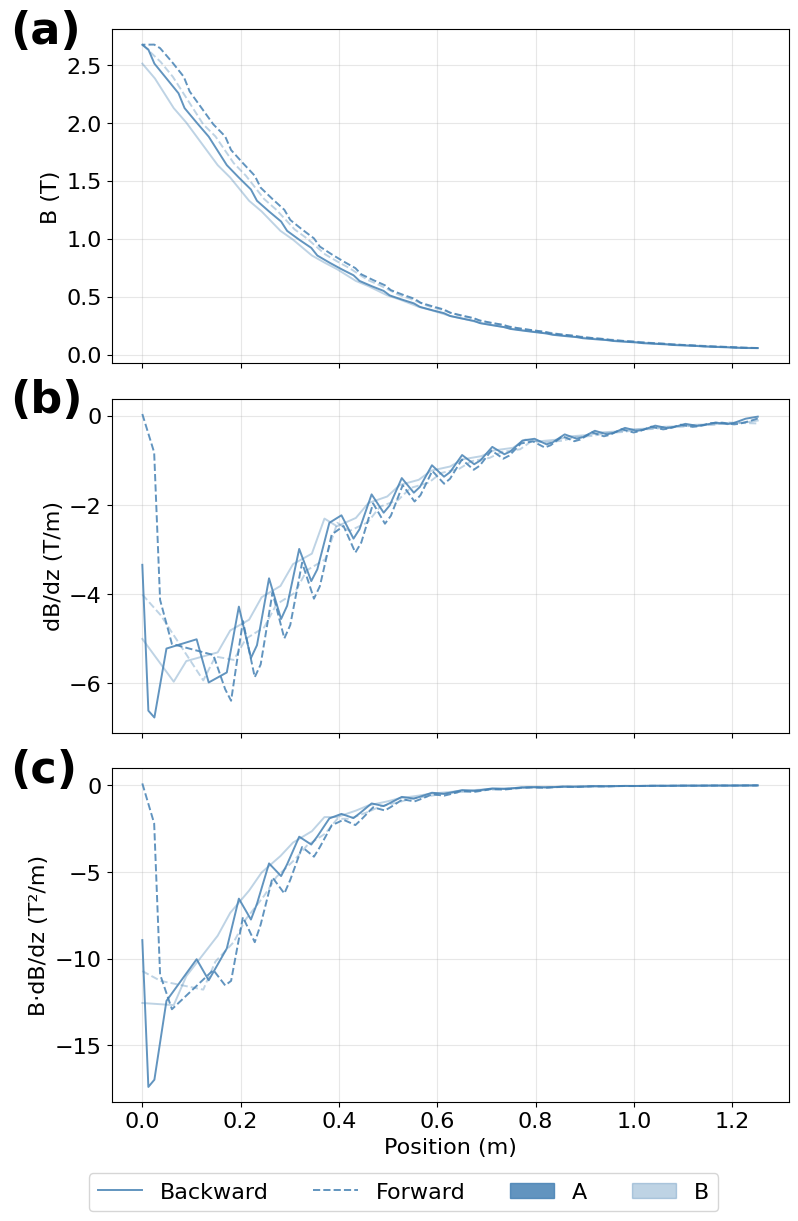

In [15]:
import matplotlib.patches as mpatches

def plot_coordinate(prefix, show=False):
    fwd_keys, bwd_keys = get_pass_keys(prefix)

    BASE_COLOR = 'steelblue'
    SUBA_ALPHA = 0.85
    SUBB_ALPHA = 0.35

    def sub_style(sub, pass_label):
        return dict(
            color=BASE_COLOR,
            lw=1.4,
            alpha=SUBA_ALPHA if sub == 'A' else SUBB_ALPHA,
            linestyle='--' if pass_label == 'fwd' else '-',
        )

    panel_labels = ["(a)", "(b)", "(c)"]
    fig, axes = plt.subplots(3, 1, figsize=(8, 12),sharex=True)

    pass_map = {'bwd': bwd_keys, 'fwd': fwd_keys}

    # ===================== ROW 0: B =====================
    ax = axes[0]
    for pass_label, keys in pass_map.items():
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position_m'].notna() & df['B_T'].notna()
                ax.plot(df.loc[ok, 'position_m'], df.loc[ok, 'B_T'],
                        **sub_style(sub, pass_label))
    ax.set_ylabel('B (T)', fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=label_size)
    ax.text(-0.15, 1.06, panel_labels[0], transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

    # ===================== ROW 1: dB/dz =====================
    ax = axes[1]
    for pass_label, keys in pass_map.items():
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position_m'].notna() & df['B_T'].notna()
                if ok.sum() < 3: continue
                z_m, dBdz, _ = central_diff(df.loc[ok,'position_m'].values, df.loc[ok,'B_T'].values)
                ok_g = np.isfinite(dBdz)
                ax.plot(z_m[ok_g], dBdz[ok_g], **sub_style(sub, pass_label))
    ax.set_ylabel('dB/dz (T/m)', fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=label_size)
    ax.text(-0.15, 1.06, panel_labels[1], transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

    # ===================== ROW 2: B·dB/dz =====================
    ax = axes[2]
    for pass_label, keys in pass_map.items():
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position_m'].notna() & df['B_T'].notna()
                if ok.sum() < 3: continue
                z_m, dBdz, B_bin = central_diff(df.loc[ok,'position_m'].values, df.loc[ok,'B_T'].values)
                BgradB = B_bin * dBdz
                ok_bg  = np.isfinite(BgradB)
                ax.plot(z_m[ok_bg], BgradB[ok_bg], **sub_style(sub, pass_label))
    ax.set_ylabel('B·dB/dz (T²/m)', fontsize=label_size)
    ax.set_xlabel('Position (m)', fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=label_size)
    ax.text(-0.15, 1.06, panel_labels[2], transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

    # ── single shared legend, centred below all panels ─────────────────────
    from matplotlib.lines import Line2D
    legend_handles = [
        # Direction (linestyle)
        Line2D([0],[0], color=BASE_COLOR, lw=1.4, ls='-',  alpha=SUBA_ALPHA, label='Backward'),
        Line2D([0],[0], color=BASE_COLOR, lw=1.4, ls='--', alpha=SUBA_ALPHA, label='Forward'),
        # Sub-run (alpha/shade)
        mpatches.Patch(color=BASE_COLOR, alpha=SUBA_ALPHA, label='A'),
        mpatches.Patch(color=BASE_COLOR, alpha=SUBB_ALPHA, label='B'),
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,                   # all 4 entries in one horizontal row
        fontsize=label_size,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),  # anchor to bottom-centre of the figure
    )

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.08)   # carve out space for the legend
    fig.savefig(f'{PLOTS_DIR}/{prefix}_All3vsPosition.png', dpi=300, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close()

plot_coordinate('G6',True)

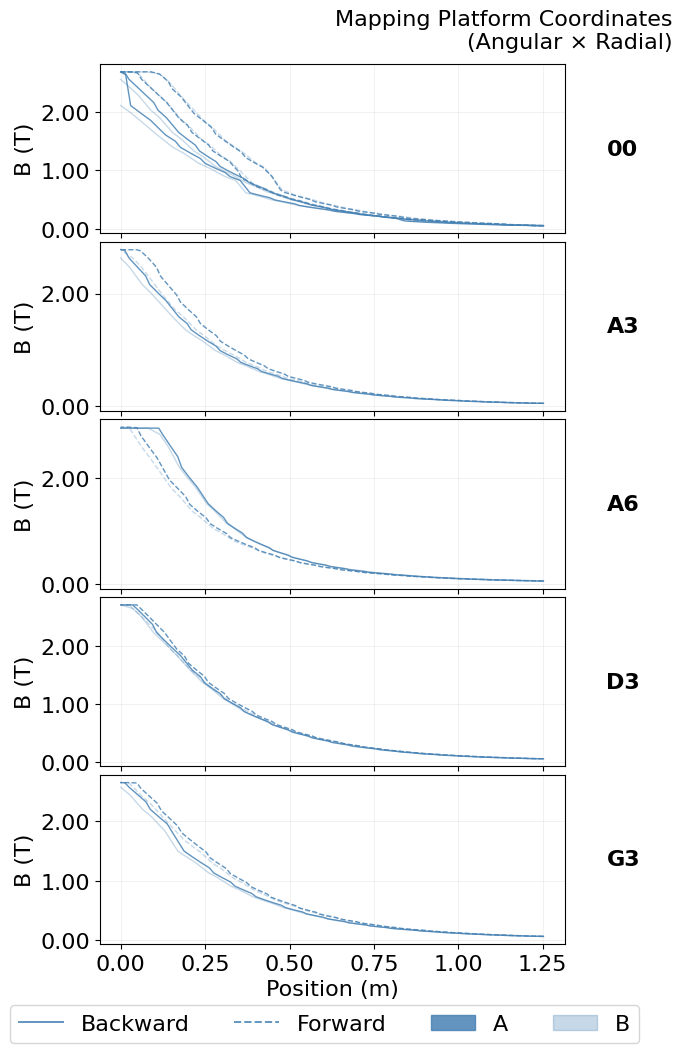

Saved allCoords_betterPlots/summary_B.png


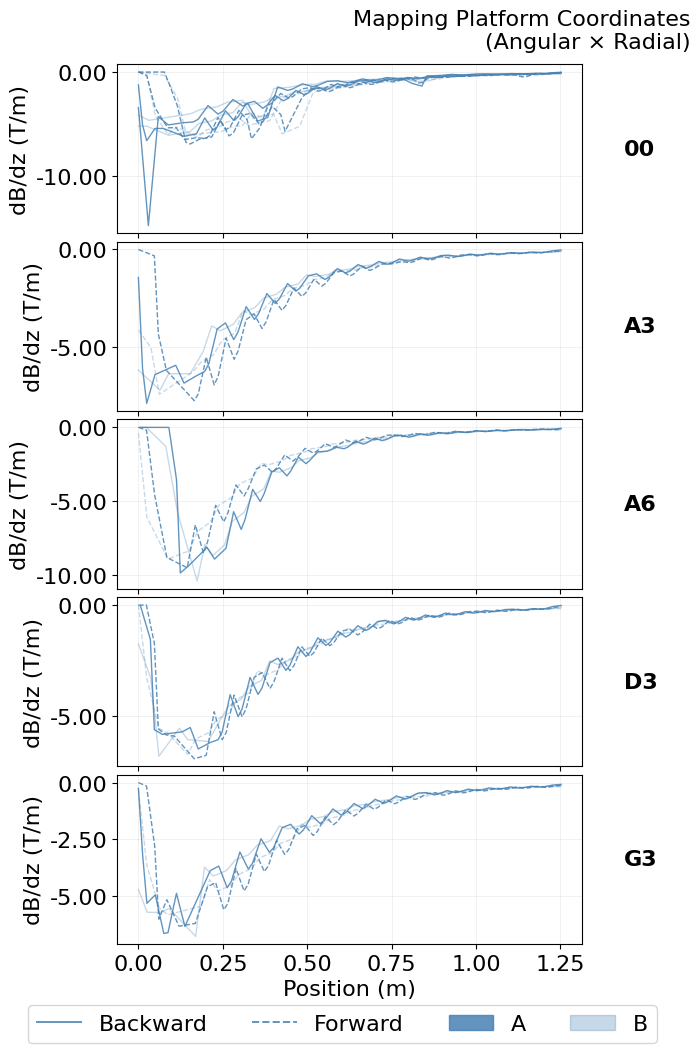

Saved allCoords_betterPlots/summary_dBdz.png


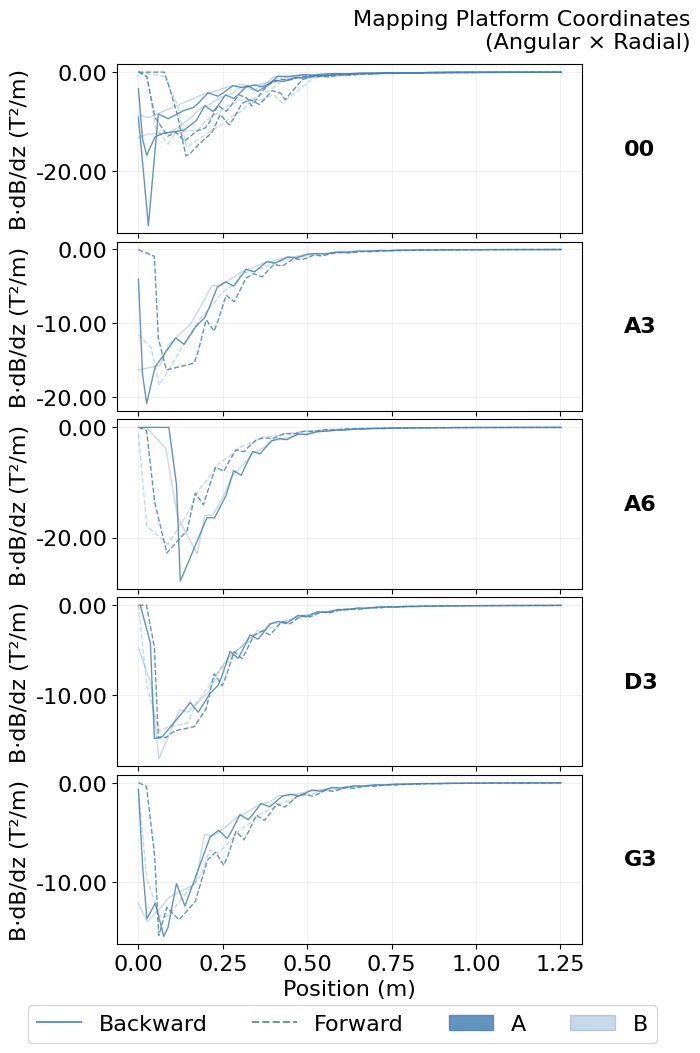

Saved allCoords_betterPlots/summary_BgradB.png


In [16]:
def make_summary_figure(plot_type):
    nrows = len(SUMMARY_PREFIXES)

    fig, axes = plt.subplots(
        nrows, 1,
        figsize=(6, 2.2 * nrows),
        sharex=True,
        gridspec_kw=dict(hspace=0.05)
    )

    y_labels = {
        'B':      'B (T)',
        'dBdz':   'dB/dz (T/m)',
        'BgradB': r'B·dB/dz (T²/m)',
    }

    BASE_COLOR = 'steelblue'
    SUBA_ALPHA = 0.85
    SUBB_ALPHA = 0.30

    def sub_style(sub, pass_label):
        return dict(
            color=BASE_COLOR,
            lw=1.0,
            alpha=SUBA_ALPHA if sub == 'A' else SUBB_ALPHA,
            linestyle='-' if pass_label == 'bwd' else '--',
        )

    for row, prefix in enumerate(SUMMARY_PREFIXES):
        fwd_keys, bwd_keys = get_pass_keys(prefix)
        ax = axes[row]

        for pass_label, keys in [('bwd', bwd_keys), ('fwd', fwd_keys)]:
            for key in keys:
                for sub, df in mapped[key].items():
                    ok = df['position_m'].notna() & df['B_T'].notna()
                    if ok.sum() < 3:
                        continue

                    pos = df.loc[ok, 'position_m'].values
                    B   = df.loc[ok, 'B_T'].values

                    if plot_type == 'B':
                        ax.plot(pos, B, **sub_style(sub, pass_label))

                    elif plot_type == 'dBdz':
                        z_m, dBdz, _ = central_diff(pos, B)
                        ok_g = np.isfinite(dBdz)
                        ax.plot(z_m[ok_g], dBdz[ok_g], **sub_style(sub, pass_label))

                    elif plot_type == 'BgradB':
                        z_m, dBdz, B_bin = central_diff(pos, B)
                        BgradB = B_bin * dBdz
                        ok_bg  = np.isfinite(BgradB)
                        ax.plot(z_m[ok_bg], BgradB[ok_bg], **sub_style(sub, pass_label))

        ax.grid(True, alpha=0.25, lw=0.5)
        ax.tick_params(labelsize=label_size)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.set_ylabel(y_labels[plot_type], fontsize=label_size)

        # Coord label on the right of each row
        ax.annotate(
            prefix,
            xy=(1.09, 0.5), xycoords='axes fraction',
            fontsize=label_size, fontweight='bold', va='center', ha='left',
        )

    axes[-1].set_xlabel('Position (m)', fontsize=label_size)

    # ── single shared legend, centred below all panels ─────────────────────
    from matplotlib.lines import Line2D
    legend_handles = [
        # Direction (linestyle)
        Line2D([0],[0], color=BASE_COLOR, lw=1.4, ls='-',  alpha=SUBA_ALPHA, label='Backward'),
        Line2D([0],[0], color=BASE_COLOR, lw=1.4, ls='--', alpha=SUBA_ALPHA, label='Forward'),
        # Sub-run (alpha/shade)
        mpatches.Patch(color=BASE_COLOR, alpha=SUBA_ALPHA, label='A'),
        mpatches.Patch(color=BASE_COLOR, alpha=SUBB_ALPHA, label='B'),
    ]
    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,                   # all 4 entries in one horizontal row
        fontsize=label_size,
        frameon=True,
        bbox_to_anchor=(0.5, -0.02),  # anchor to bottom-centre of the figure
    )

    fig.subplots_adjust(bottom=0.08)   # carve out space for the legend
    fig.text(
        1.08, 0.93,
        'Mapping Platform Coordinates\n(Angular × Radial)',
        fontsize=label_size,
        va='top',
        ha='right',
    )

    out_path = SUMMARY_DIR / f'summary_{plot_type}.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Saved {out_path}')


for pt in ['B', 'dBdz', 'BgradB']:
    make_summary_figure(pt)

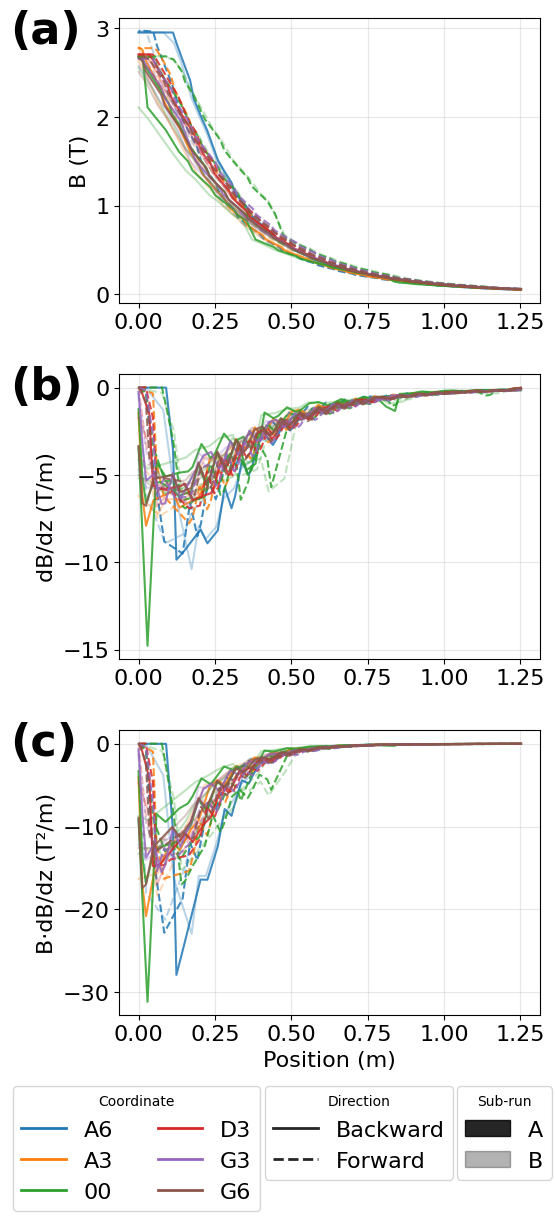

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(6, 12))
plot_types = ['B', 'dBdz', 'BgradB']
y_labels = {
    'B':      'B (T)',
    'dBdz':   'dB/dz (T/m)',
    'BgradB': r'B·dB/dz (T²/m)',
}
panel_labels = ['(a)', '(b)', '(c)']

# ---------- VISUAL MAPS ----------
prefix_colors    = dict(zip(PREFIXES, plt.cm.tab10.colors[:len(PREFIXES)]))
direction_styles = {'bwd': '-', 'fwd': '--'}
subrun_alpha     = {'A': 0.85, 'B': 0.30}

for ax, plot_type, lab in zip(axes, plot_types, panel_labels):
    for prefix in PREFIXES:
        fwd_keys, bwd_keys = get_pass_keys(prefix)
        for pass_label, keys in [('bwd', bwd_keys), ('fwd', fwd_keys)]:
            for key in keys:
                for sub, df in mapped[key].items():
                    ok = df['position_m'].notna() & df['B_T'].notna()
                    if ok.sum() < 3:
                        continue
                    pos   = df.loc[ok, 'position_m'].values
                    B     = df.loc[ok, 'B_T'].values
                    color = prefix_colors[prefix]
                    ls    = direction_styles[pass_label]
                    alpha = subrun_alpha[sub]

                    if plot_type == 'B':
                        ax.plot(pos, B, color=color, ls=ls, alpha=alpha, lw=1.5)
                    elif plot_type == 'dBdz':
                        z_m, dBdz, _ = central_diff(pos, B)
                        ok_g = np.isfinite(dBdz)
                        ax.plot(z_m[ok_g], dBdz[ok_g],
                                color=color, ls=ls, alpha=alpha, lw=1.5)
                    elif plot_type == 'BgradB':
                        z_m, dBdz, B_bin = central_diff(pos, B)
                        BgradB = B_bin * dBdz
                        ok_bg  = np.isfinite(BgradB)
                        ax.plot(z_m[ok_bg], BgradB[ok_bg],
                                color=color, ls=ls, alpha=alpha, lw=1.5)

    ax.set_ylabel(y_labels[plot_type], fontsize=label_size)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=label_size)
    ax.text(-0.26, 1.03, lab, transform=ax.transAxes,
            fontsize=fig_labelsize, fontweight='bold', va='top', ha='left')

axes[-1].set_xlabel('Position (m)', fontsize=label_size)

# ---------- LEGEND ----------
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

coord_handles = [
    Line2D([0],[0], color=prefix_colors[p], lw=2, label=p) for p in PREFIXES
]
dir_handles = [
    Line2D([0],[0], color='k', lw=2, ls='-',  alpha=0.85, label='Backward'),
    Line2D([0],[0], color='k', lw=2, ls='--', alpha=0.85, label='Forward'),
]
sub_handles = [
    mpatches.Patch(color='k', alpha=0.85, label='A'),
    mpatches.Patch(color='k', alpha=0.30, label='B'),
]

leg2 = axes[-1].legend(handles=dir_handles, ncol=1,
                        fontsize=label_size, frameon=True,
                        bbox_to_anchor=(0.45, 0.1),
                        bbox_transform=fig.transFigure,
                        loc='upper left', title='Direction')

leg3 = axes[-1].legend(handles=sub_handles, ncol=1,
                        fontsize=label_size, frameon=True,
                        bbox_to_anchor=(0.77, 0.1),
                        bbox_transform=fig.transFigure,
                        loc='upper left', title='Sub-run')

leg1 = axes[-1].legend(handles=coord_handles, ncol=2,
                        fontsize=label_size, frameon=True,
                        bbox_to_anchor=(0.03, 0.1),
                        bbox_transform=fig.transFigure,
                        loc='upper left', title='Coordinate')


axes[-1].add_artist(leg2)
axes[-1].add_artist(leg3)
# leg3 is the active legend, no add_artist needed

plt.tight_layout()
plt.subplots_adjust(hspace=0.25, bottom=0.15)
out_path = SUMMARY_DIR / f'summary_vertical_overlay_clean.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

In [18]:
prefix_colors

{'A6': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'A3': (1.0, 0.4980392156862745, 0.054901960784313725),
 '00': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'D3': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'G3': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'G6': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)}